In [1]:
import tensorflow as tf
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


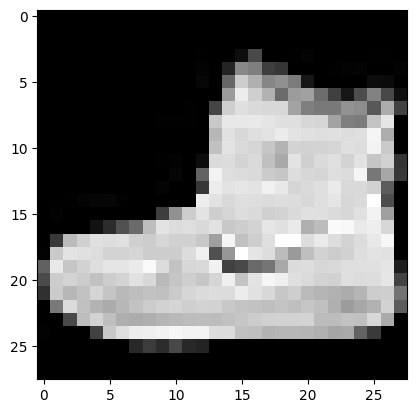

In [3]:
plt.imshow(X_train[0], cmap="gray")

In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
X_test.shape

(10000, 28, 28)

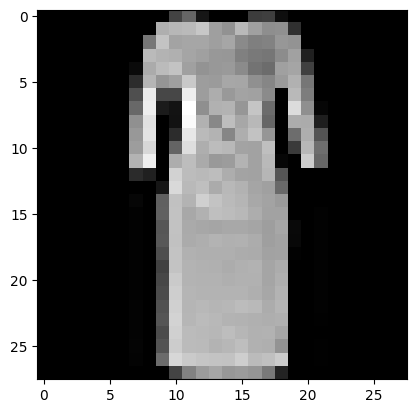

In [6]:
i = random.randint(1,60000)
plt.imshow( X_train[i] , cmap = 'gray')

In [7]:
label = y_train[i]
label
np.uint8(4)

np.uint8(4)

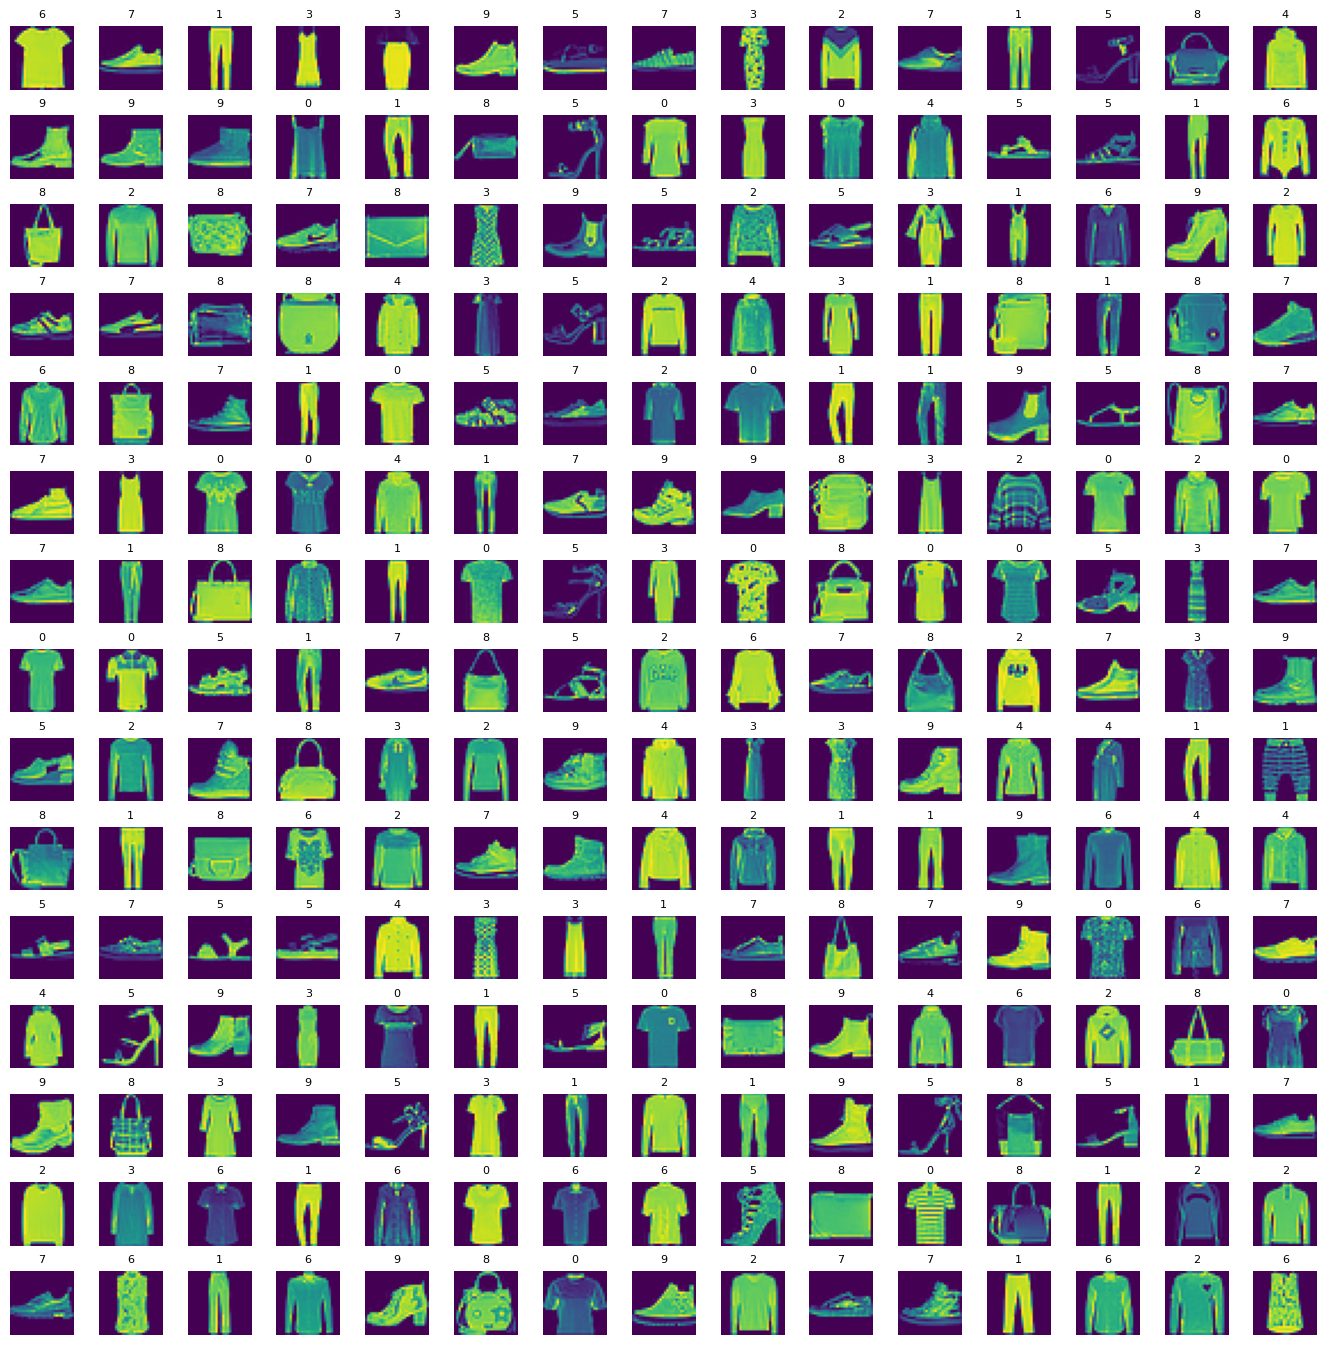

In [9]:
W_grid = 15
L_grid = 15
fig, axes = plt.subplots(L_grid, W_grid, figsize = (17,17))
axes = axes.ravel()
n_training = len(X_train)
for i in np.arange(0, W_grid * L_grid):
   index = np.random.randint(0, n_training)
   axes[i].imshow( X_train[index] )
   axes[i].set_title(y_train[index], fontsize = 8)
   axes[i].axis('off')
plt.subplots_adjust(hspace=0.4)

In [13]:
X_train = X_train /255
X_test = X_test /255

In [14]:
noise_factor = 0.3
noise_dataset = []

In [15]:
for img in X_train:
   noisy_image = img + noise_factor * np.random.randn(*img.shape)
   noisy_image = np.clip(noisy_image,0.,1.)
   noise_dataset.append(noisy_image)

In [16]:
noise_dataset = np.array(noise_dataset)

In [17]:
noise_dataset.shape

(60000, 28, 28)

In [18]:
noise_test_set = []

In [20]:
for img in X_test:

  noisy_image = img + noise_factor * np.random.randn(*img.shape)
  noisy_image = np.clip(noisy_image, 0., 1.)
  noise_test_set.append(noisy_image)

In [21]:
noise_test_set = np.array(noise_test_set)

In [22]:
noise_test_set.shape

(10000, 28, 28)

In [23]:
autoencoder = tf.keras.models.Sequential()

In [24]:
#Encoder
autoencoder.add(tf.keras.layers.Conv2D(filters=16, kernel_size=3, strides=2, padding="same", input_shape=(28, 28, 1)))
autoencoder.add(tf.keras.layers.Conv2D(filters=8, kernel_size=3, strides=2, padding="same"))
#Encoded image
autoencoder.add(tf.keras.layers.Conv2D(filters=8, kernel_size=3, strides=1, padding="same"))
#Decoder
autoencoder.add(tf.keras.layers.Conv2DTranspose(filters=16, kernel_size=3, strides=2, padding="same"))
autoencoder.add(tf.keras.layers.Conv2DTranspose(filters=1, kernel_size=3, strides=2, activation='sigmoid', padding="same"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
autoencoder.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(0.001), metrics=["accuracy"])

In [26]:
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │           145 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
autoencoder.fit(noise_dataset.reshape(-1,28,28,1),
                X_train.reshape(-1,28,28,1),
                 epochs = 10,
                batch_size = 200,
                validation_data = (noise_test_set.reshape(-1,28,28,1),X_test.reshape(-1,28,28,1)))

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4980 - loss: 0.3971 - val_accuracy: 0.5050 - val_loss: 0.3264
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5078 - loss: 0.3170 - val_accuracy: 0.5060 - val_loss: 0.3149
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5085 - loss: 0.3097 - val_accuracy: 0.5065 - val_loss: 0.3097
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5088 - loss: 0.3062 - val_accuracy: 0.5067 - val_loss: 0.3075
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5089 - loss: 0.3046 - val_accuracy: 0.5067 - val_loss: 0.3062
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5090 - loss: 0.3035 - val_accuracy: 0.5068 - val_loss: 0.3053
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5091 - loss: 0.3026 - val_accuracy: 0.5069 - val_loss: 0.3046
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5091 - loss: 0.3019 - val_accuracy: 0.

In [28]:
evaluation = autoencoder.evaluate(noise_test_set.reshape(-1, 28, 28, 1), X_test.reshape(-1, 28, 28, 1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5070 - loss: 0.3030
